In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.metrics import balanced_accuracy_score, accuracy_score
from tqdm import tqdm

from models import make
from models.t0 import T0RegressionModel
from datahandles import FewShotDataset
from utils import load_cfg

os.environ["HF_HOME"] = "/export/pasan/.cache/huggingface"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

/afs/glue.umd.edu/home/glue/p/a/pasand/home/miniconda3/envs/transhyper2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
checkpoint_path = f"save/tabpfn-bank-n64/epoch-best-balacc.pth"
checkpoint = torch.load(checkpoint_path, weights_only=False)
cfg = load_cfg(cfg_dict=checkpoint["cfg"])
model = make(model_name=cfg.hypernet.name, cfg=cfg, sd=checkpoint["model"]).cuda()

if "tokenizer" in cfg.keys():
    tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer.model)

Hyponet mlp initialized with parameter shapes {'wb0': (53, 10), 'wb1': (11, 10), 'wb2': (11, 10), 'wb3': (11, 2)}
Initializing hypernet tabpfn, name: tabpfn
total hyponet params: 772


In [3]:
vals_to_print = {
    '# shots': cfg.datasets.n_shots,
    '# queries': cfg.datasets.n_queries,
    '# meta examples': cfg.datasets.train_size,
    'total training set size': cfg.datasets.n_shots * cfg.datasets.train_size if cfg.datasets.queries_same_as_shots else (cfg.datasets.n_queries + cfg.datasets.n_shots) * cfg.datasets.train_size,
    'queries same as shots?': cfg.datasets.queries_same_as_shots,
    'with random permutations?': cfg.datasets.train_permutation
}

print(f"training setup:")
for key, val in vals_to_print.items():
    print(f"{key}: {val}")


training setup:
# shots: 64
# queries: 64
# meta examples: 1
total training set size: 64
queries same as shots?: True
with random permutations?: True


# Utils

In [4]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, normalize=False, cmap='Blues'):
    """
    Displays a confusion matrix.

    Parameters:
    - y_true: list or array of true labels
    - y_pred: list or array of predicted labels
    - class_names: list of class names (optional)
    - normalize: whether to normalize the matrix (default: False)
    - cmap: color map for the heatmap
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap=cmap,
                xticklabels=class_names if class_names else 'auto',
                yticklabels=class_names if class_names else 'auto')
    
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix' + (' (Normalized)' if normalize else ''))
    plt.tight_layout()
    plt.show()

In [5]:
def load_dataset(
                  test_list: list,
                  n_shots:int,
                  n_queries:int,
                  max_n_features: int | None,
                  test_size:int = 1,
                  test_permutation:bool = False,
                ):
        
    train_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root,
        split='train',
        split_size=cfg.datasets.train_size,
        n_shots=cfg.datasets.n_shots,
        n_queries=cfg.datasets.n_queries,
        queries_same_as_shots=cfg.datasets.queries_same_as_shots,
        max_n_features=max_n_features,
        balance_labels=True, ############################################# see why cfg is not working
        col_permutation=False,
        shuffle=False,
        debug=False,
        shots_with_labels=False
    )

    test_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root,
        split='test',
        split_size=test_size,
        n_shots=n_shots,
        n_queries=n_queries,
        queries_same_as_shots=True,
        max_n_features=max_n_features,
        balance_labels=False,
        col_permutation=test_permutation,
        shuffle=True,
        debug=False,
        shots_with_labels=False
    )
    
    print(f"dataset length: {len(test_ds)}, # queries: {len(test_ds[0]['queries_y'])}")
    return test_ds, train_ds

def get_hyponet(queries):
    # print(f"devices -- queries: {queries.device}, model: {model.device}")      
    return model(queries)

# Hyponet evaluate

In [6]:
the_train_ds = None
the_test_ds = None
def compute_metrics(queries, X, y):
    hyponet = get_hyponet(queries=queries)
    hyponet.eval()
    preds = hyponet.forward(torch.tensor(X).unsqueeze(dim=0).cuda())
    preds = preds.detach().cpu().numpy()
    preds = np.squeeze(preds)
    y_pred = np.argmax(preds, axis=1)

    val_counts = pd.DataFrame(y).value_counts()
    const_pred_acc = max(val_counts)/sum(val_counts)
    balanced_acc = balanced_accuracy_score(y, y_pred)
    unbalanced_acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, preds[:,1])

    return {
        "const_predictor_acc": const_pred_acc,
        "balanced_acc": balanced_acc,
        "unbalanced_acc": unbalanced_acc,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

def compute_avg_metrics(ds_name, n_shots, n_queries, n_samples, max_n_features):
    if n_shots < 1:
        test_ds, train_ds = load_dataset(test_list=[ds_name],
                                    n_shots=n_queries,
                                    n_queries=n_queries,
                                    test_size=n_samples,
                                    max_n_features=max_n_features
                                )
    else:
        test_ds, train_ds = load_dataset(test_list=[ds_name],
                                    n_shots=n_shots,
                                    n_queries=n_queries,
                                    test_size=n_samples,
                                    max_n_features=max_n_features
                                )
    
    # print(f"sample shots (train):\n{train_ds[0]['shots']}")
    # print(f"sample shots (test):\n{test_ds[0]['shots']}")

    avg_metrics = {}
    for i in range(n_samples):
        if n_queries < 1:
            print("Number of queries cannot be smaller than 1.")
        else:
            queries = train_ds[0]
        X = torch.tensor(test_ds[i]['queries_x'])
        y = torch.tensor(test_ds[i]['queries_y'])
        metrics = compute_metrics(queries=queries, X=X, y=y)
        for key, val in metrics.items():
            if key in avg_metrics.keys():
                avg_metrics[key] += val
            else:
                avg_metrics[key] = val

    avg_metrics = {key: val / n_samples for key, val in avg_metrics.items()}
    return avg_metrics

dataset length: 1, # queries: 43211


/tmp/ipykernel_893080/1077335262.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(test_ds[i]['queries_x'])
/tmp/ipykernel_893080/1077335262.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(test_ds[i]['queries_y'])
/tmp/ipykernel_893080/1077335262.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  preds = hyponet.forward(torch.tensor(X).unsqueeze(dim=0).cuda())


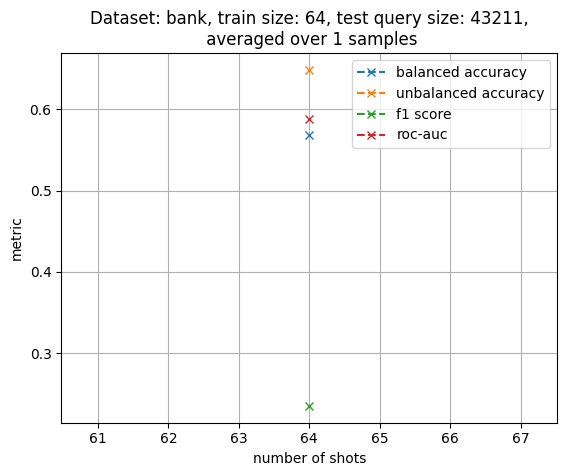

['64: 0.59']
max values:
balanced acc 0.57 at 64 shots
unbalanced acc 0.65 at 64 shots
f1 score 0.24 at 64 shots
roc-auc 0.59 at 64 shots


In [7]:
ds_name = cfg.datasets.list_combine_train[0]
max_n_features = cfg.hyponet.in_dim
n_samples = 1

n_queries_dict = {"bank": 43211, "calhousing": 19640, "income": 44222}

n_queries = n_queries_dict[ds_name]

# n_shots_list = [1,]
n_shots_list = [cfg.datasets.n_queries]
# n_shots_list = [100]

balanced_acc = []
unbalanced_acc = []
f1 = []
roc_auc = []
for n_shots in n_shots_list:
    metrics = compute_avg_metrics(ds_name=ds_name, 
                                  n_shots=n_shots, 
                                  n_queries=n_queries, 
                                  n_samples=n_samples,
                                  max_n_features=max_n_features)
    balanced_acc.append(metrics['balanced_acc'])
    unbalanced_acc.append(metrics['unbalanced_acc'])
    f1.append(metrics['f1_score'])
    roc_auc.append(metrics['roc_auc'])

# x_vals = list(range(len(n_shots_list)))
x_vals = n_shots_list
    
plt.plot(x_vals, balanced_acc, 'x--', label="balanced accuracy")
plt.plot(x_vals, unbalanced_acc, 'x--', label="unbalanced accuracy")
plt.plot(x_vals, f1, 'x--', label='f1 score')
plt.plot(x_vals, roc_auc, 'x--', label='roc-auc')
plt.title(f"Dataset: {ds_name}, train size: {vals_to_print['total training set size']}, test query size: {n_queries},\n averaged over {n_samples} samples")
plt.xlabel("number of shots")
plt.ylabel("metric")
# plt.xticks(ticks=range(max(n_shots_list)+1))
# plt.yticks(ticks=np.arange(0, 1, 0.05))
plt.grid(visible=True, which='both')
plt.legend()
plt.show()

b_acc_max_idx = np.argmax(balanced_acc, axis=0)
ub_acc_max_idx = np.argmax(unbalanced_acc, axis=0)
f1_max_idx = np.argmax(f1, axis=0)
roc_auc_max_idx = np.argmax(roc_auc, axis=0)
print([f"{x_vals[i]}: {roc_auc[i]:.2}" for i in range(len(x_vals))])
print("max values:")
print(f"balanced acc {balanced_acc[b_acc_max_idx]:.2} at {n_shots_list[b_acc_max_idx]} shots")
print(f"unbalanced acc {unbalanced_acc[ub_acc_max_idx]:.2} at {n_shots_list[ub_acc_max_idx]} shots")
print(f"f1 score {f1[f1_max_idx]:.2} at {n_shots_list[f1_max_idx]} shots")
print(f"roc-auc {roc_auc[roc_auc_max_idx]:.2} at {n_shots_list[roc_auc_max_idx]} shots")